In [2]:
import os
import os.path as osp

from PIL import Image
import torch
from transformers import AutoModel, AutoImageProcessor

In [9]:
from pathlib import Path

# Simple function to load all images from a folder
def load_all_images(folder_path):
    """Load all image files from the specified folder."""
    folder = Path(folder_path)
    image_extensions = {'.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.webp', '.gif'}
    
    images = []
    image_names = []
    image_paths = []
    
    # Get all files and filter for images
    for file_path in sorted(folder.iterdir()):
        if file_path.is_file() and file_path.suffix.lower() in image_extensions:
            try:
                images.append(Image.open(file_path))
                image_names.append(file_path.stem)  # filename without extension
                image_paths.append(str(file_path))
                print(f"Loaded: {file_path.name}")
            except Exception as e:
                print(f"Failed to load {file_path.name}: {e}")
    
    return images, image_names, image_paths

# Usage - replace your hardcoded section with this:
folder_path = "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/"
images, image_names, image_paths = load_all_images(folder_path)


Loaded: graph_theory1.png
Loaded: line_chart.png
Loaded: logo1.png
Loaded: logo2.png
Loaded: math_draft1.png
Loaded: menu.jpeg
Loaded: physics1.png
Loaded: physics2.png


In [3]:
MODEL_HUB = "BAAI/Emu3-VisionTokenizer"

model = AutoModel.from_pretrained(MODEL_HUB, trust_remote_code=True).eval().cuda()
processor = AutoImageProcessor.from_pretrained(MODEL_HUB, trust_remote_code=True)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [7]:
# Load both images
IMAGE_PATHS = [
    "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/math_draft1.png",
    "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/line_chart.png",
    "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/logo2.png",
    "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/graph_theory1.png",
    "/iopsstor/scratch/cscs/xyixuan/benchmark-image-tokenzier/assets/physics2.png",
]

images = [Image.open(path) for path in IMAGE_PATHS]
image_names = ["math_draft1", "line_chart", "logo2", "graph_theory1", "physics"]


Processing image 1: graph_theory1
Input image shape: torch.Size([1, 3, 1248, 832])
Encoded codes shape: torch.Size([1, 156, 104])
Number of tokens: 16224
Original image pixels: 1038336
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 1248, 832])


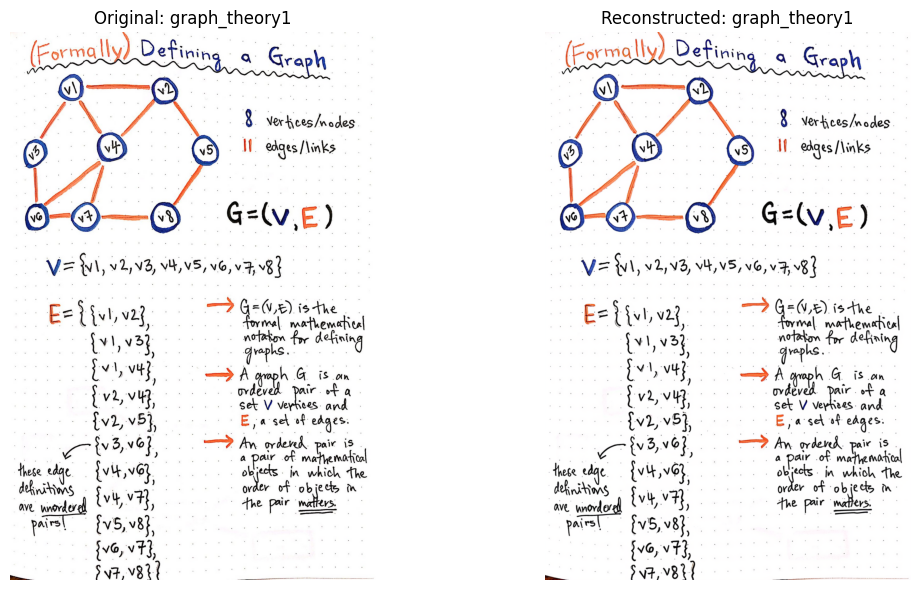


Processing image 2: line_chart
Input image shape: torch.Size([1, 3, 624, 712])
Encoded codes shape: torch.Size([1, 78, 89])
Number of tokens: 6942
Original image pixels: 444288
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 624, 712])


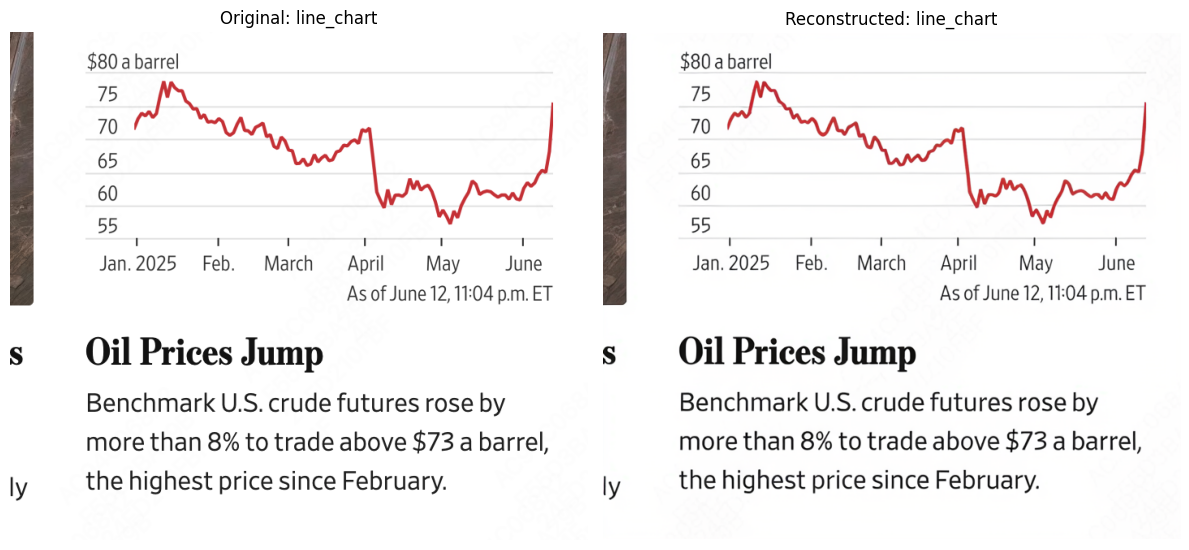


Processing image 3: logo1
Input image shape: torch.Size([1, 3, 936, 800])
Encoded codes shape: torch.Size([1, 117, 100])
Number of tokens: 11700
Original image pixels: 748800
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 936, 800])


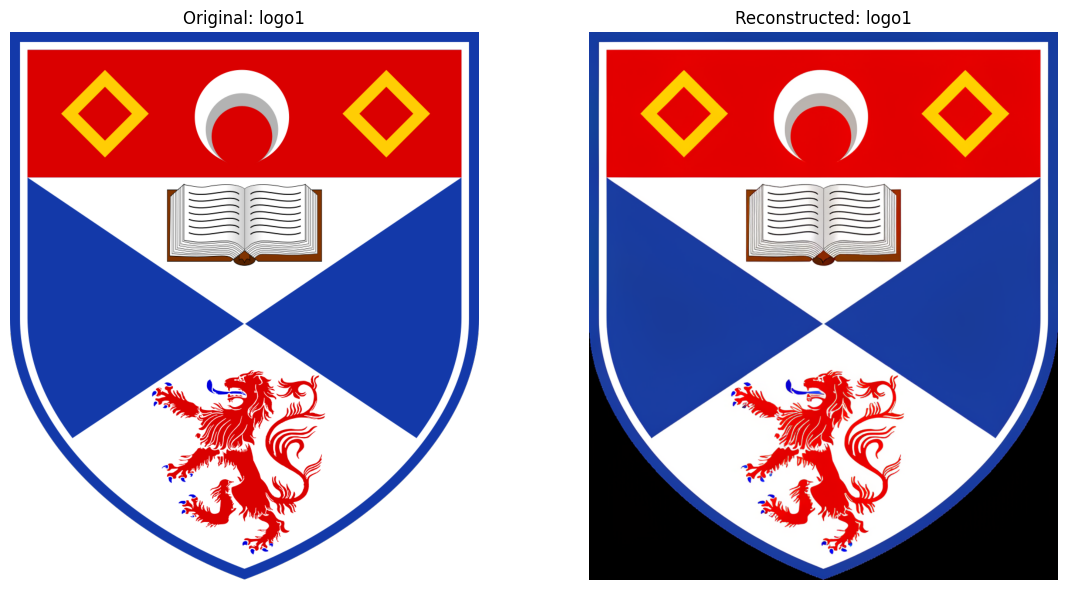


Processing image 4: logo2
Input image shape: torch.Size([1, 3, 584, 552])
Encoded codes shape: torch.Size([1, 73, 69])
Number of tokens: 5037
Original image pixels: 322368
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 584, 552])


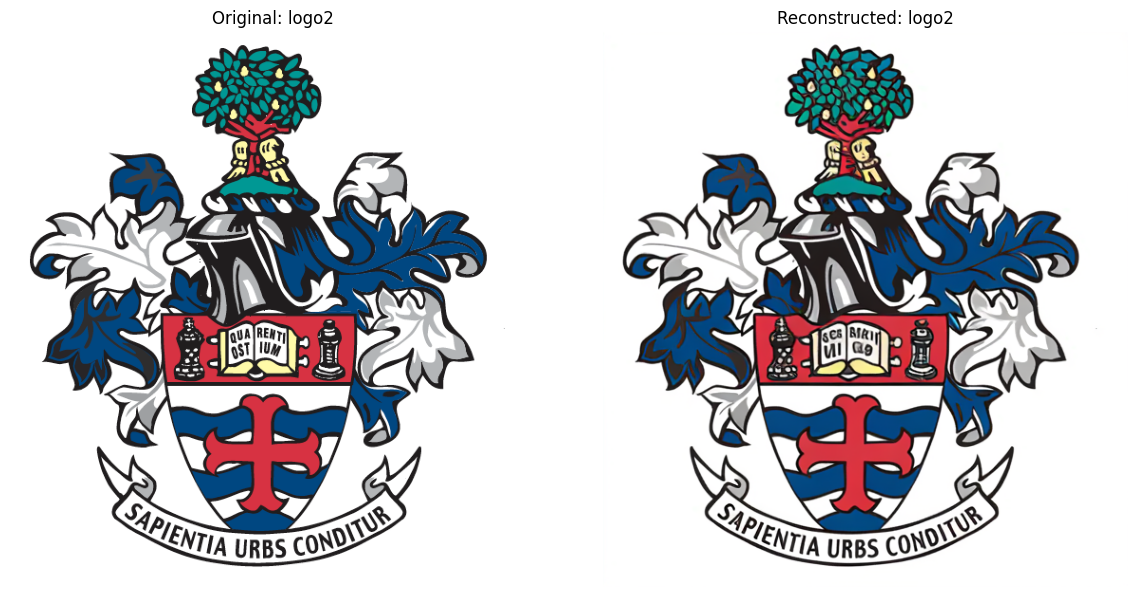


Processing image 5: math_draft1
Input image shape: torch.Size([1, 3, 864, 936])
Encoded codes shape: torch.Size([1, 108, 117])
Number of tokens: 12636
Original image pixels: 808704
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 864, 936])


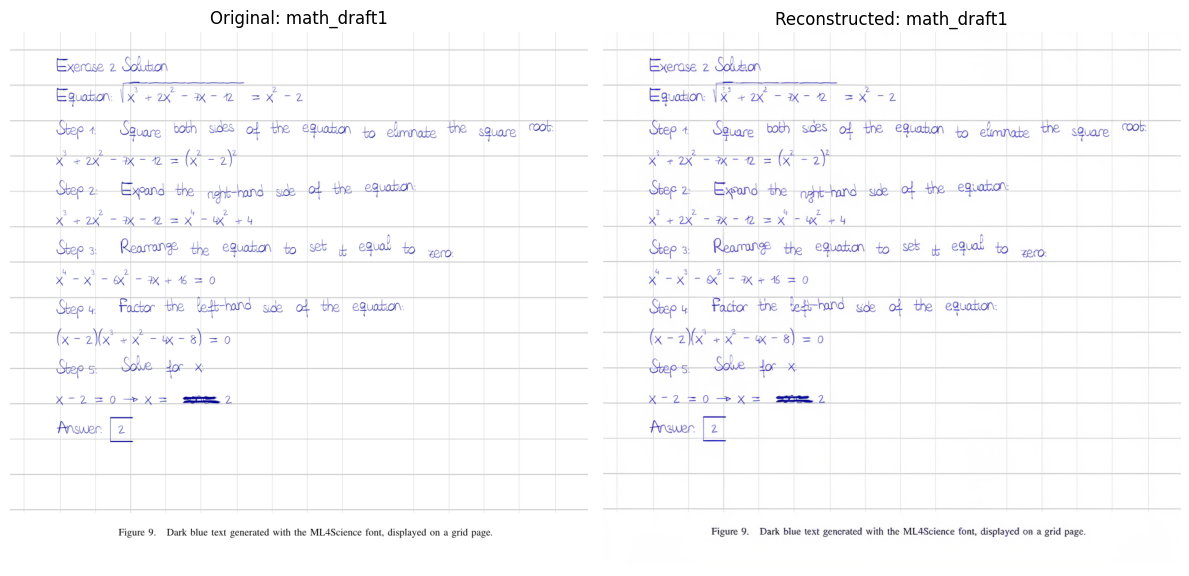


Processing image 6: menu
Input image shape: torch.Size([1, 3, 1176, 880])
Encoded codes shape: torch.Size([1, 147, 110])
Number of tokens: 16170
Original image pixels: 1034880
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 1176, 880])


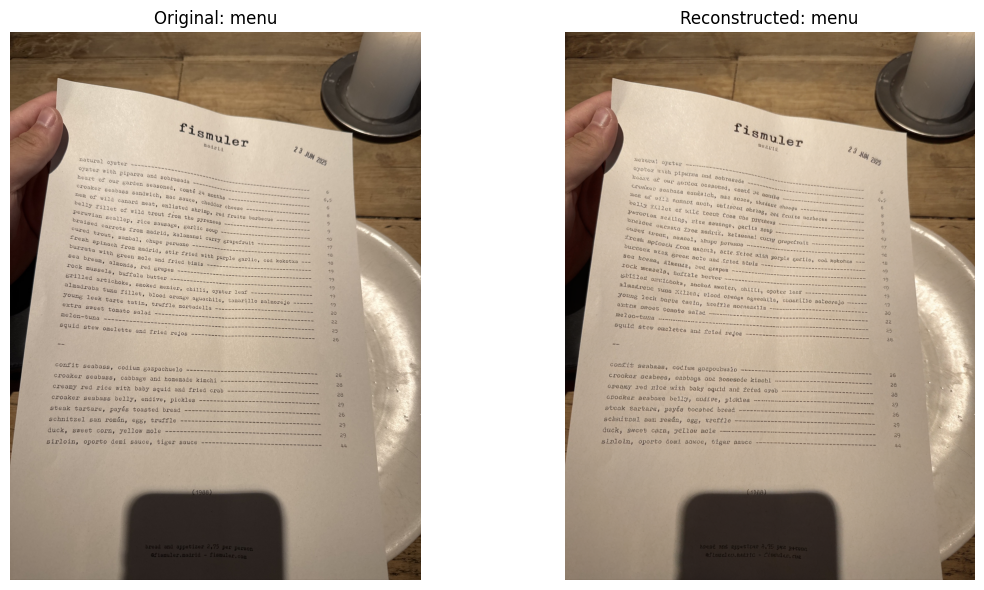


Processing image 7: physics1
Input image shape: torch.Size([1, 3, 368, 720])
Encoded codes shape: torch.Size([1, 46, 90])
Number of tokens: 4140
Original image pixels: 264960
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 368, 720])


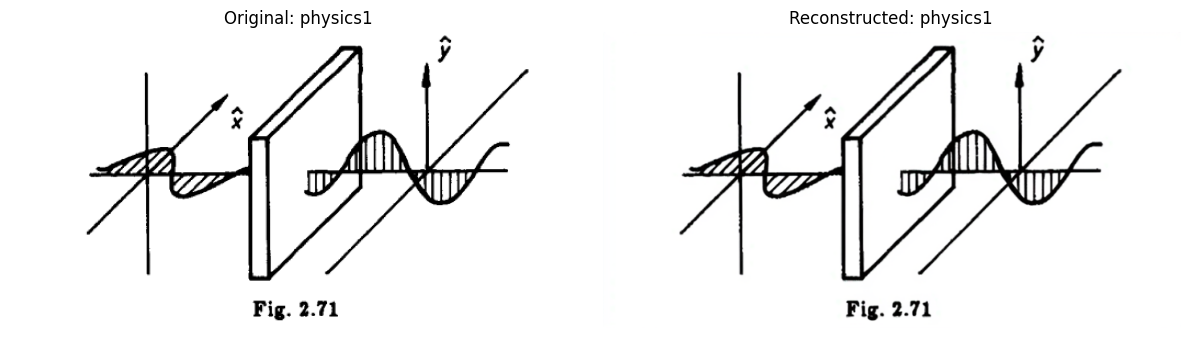


Processing image 8: physics2
Input image shape: torch.Size([1, 3, 376, 712])
Encoded codes shape: torch.Size([1, 47, 89])
Number of tokens: 4183
Original image pixels: 267712
Compression ratio: 64.00x
Reconstructed tensor shape: torch.Size([1, 3, 376, 712])


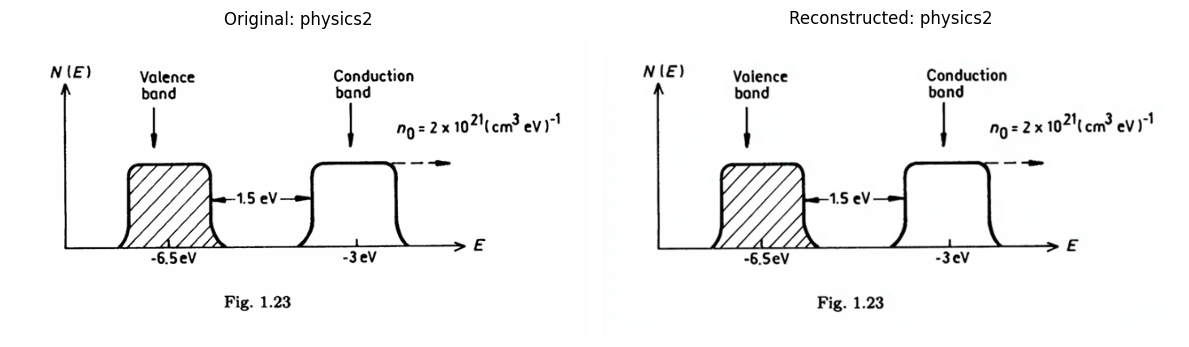


Both images processed successfully!


In [ ]:
import matplotlib.pyplot as plt

# Process and encode each image individually
for idx, (image, name) in enumerate(zip(images, image_names)):
    print(f"\nProcessing image {idx+1}: {name}")
    
    # Process single image
    image_tensor = processor([image], return_tensors="pt")["pixel_values"]
    image_tensor = image_tensor.cuda()
    
    print(f"Input image shape: {image_tensor.shape}")
    
    # Image autoencoding
    with torch.no_grad():
        # Encode the image to tokens
        codes = model.encode(image_tensor)
        print(f"Encoded codes shape: {codes.shape}")
        
        # Calculate number of tokens
        if len(codes.shape) == 3:  # [batch, height, width]
            num_tokens = codes.shape[1] * codes.shape[2]
        elif len(codes.shape) == 4:  # [batch, channels, height, width]
            num_tokens = codes.shape[2] * codes.shape[3]
        else:
            num_tokens = codes.numel() // codes.shape[0]  # total elements per batch
        
        print(f"Number of tokens: {num_tokens}")
        print(f"Original image pixels: {image_tensor.shape[-2] * image_tensor.shape[-1]}")
        compression_ratio = (image_tensor.shape[-2] * image_tensor.shape[-1]) / num_tokens
        print(f"Compression ratio: {compression_ratio:.2f}x")
        
        # Decode back to image
        recon = model.decode(codes)
        print(f"Reconstructed tensor shape: {recon.shape}")
    
    # Post-process the reconstructed image
    recon_image = processor.postprocess(recon)["pixel_values"][0]
    
    # Display comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Original image
    axes[0].imshow(image)
    axes[0].set_title(f"Original: {name}")
    axes[0].axis('off')
    
    # Reconstructed image
    axes[1].imshow(recon_image)
    axes[1].set_title(f"Reconstructed: {name}")
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()